In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

-------- Step 1: Get image from user --------

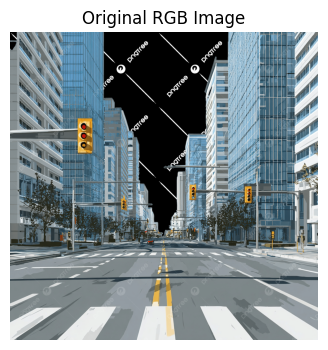

In [7]:
image_path = r"C:\Users\ds883\OneDrive\Documents\computer_vision\computer_vision\Detection operators\building image.png" 
img = cv2.imread(image_path)

if img is None:
    raise FileNotFoundError(f"Image not found at: {image_path}")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6, 4))
plt.imshow(img_rgb)
plt.title("Original RGB Image")
plt.axis("off")
plt.show()

-------- Step 2: Grayscale Preprocessing --------

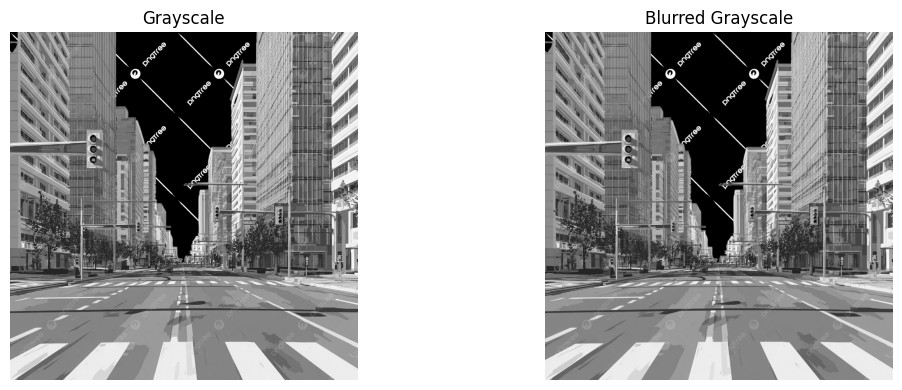

In [8]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur_gray = cv2.GaussianBlur(gray, (5, 5), 0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(gray, cmap="gray"); axes[0].set_title("Grayscale"); axes[0].axis("off")
axes[1].imshow(blur_gray, cmap="gray"); axes[1].set_title("Blurred Grayscale"); axes[1].axis("off")
plt.tight_layout(); plt.show()

Point Detection (Laplacian)

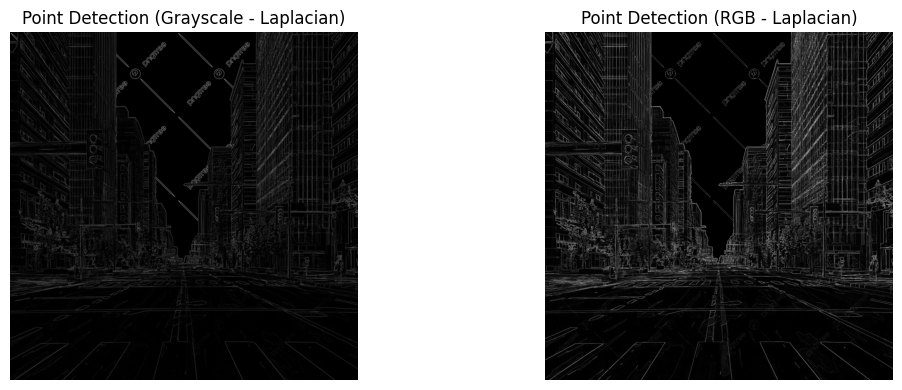

In [9]:
b, g, r = cv2.split(img)
lap_gray = cv2.Laplacian(blur_gray, cv2.CV_64F)
lap_gray = np.uint8(np.absolute(lap_gray))
lap_r = cv2.Laplacian(r, cv2.CV_64F)
lap_g = cv2.Laplacian(g, cv2.CV_64F)
lap_b = cv2.Laplacian(b, cv2.CV_64F)
lap_rgb = np.sqrt(lap_r**2 + lap_g**2 + lap_b**2)
lap_rgb = np.uint8(np.absolute(lap_rgb))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(lap_gray, cmap="gray"); axes[0].set_title("Point Detection (Grayscale - Laplacian)"); axes[0].axis("off")
axes[1].imshow(lap_rgb, cmap="gray"); axes[1].set_title("Point Detection (RGB - Laplacian)"); axes[1].axis("off")
plt.tight_layout(); plt.show()

Edge Detection - Prewitt

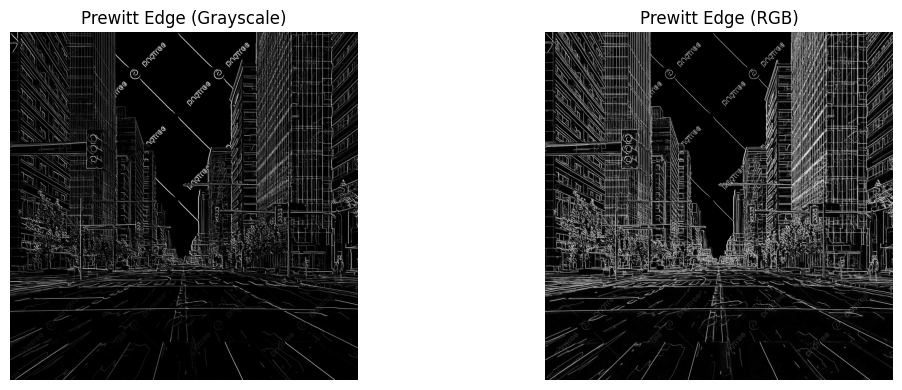

In [10]:
px = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])
py = np.array([[ 1,  1,  1], [ 0,  0,  0], [-1, -1, -1]])

prewitt_gx = cv2.filter2D(blur_gray, -1, px)
prewitt_gy = cv2.filter2D(blur_gray, -1, py)
prewitt_gray = cv2.add(prewitt_gx, prewitt_gy)

pr = cv2.add(cv2.filter2D(r, -1, px), cv2.filter2D(r, -1, py)).astype(np.float64)
pg = cv2.add(cv2.filter2D(g, -1, px), cv2.filter2D(g, -1, py)).astype(np.float64)
pb = cv2.add(cv2.filter2D(b, -1, px), cv2.filter2D(b, -1, py)).astype(np.float64)
prewitt_rgb = np.uint8(np.clip(np.sqrt(pr**2 + pg**2 + pb**2), 0, 255))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(prewitt_gray, cmap="gray"); axes[0].set_title("Prewitt Edge (Grayscale)"); axes[0].axis("off")
axes[1].imshow(prewitt_rgb, cmap="gray"); axes[1].set_title("Prewitt Edge (RGB)"); axes[1].axis("off")
plt.tight_layout(); plt.show()

Edge Detection - Sobel

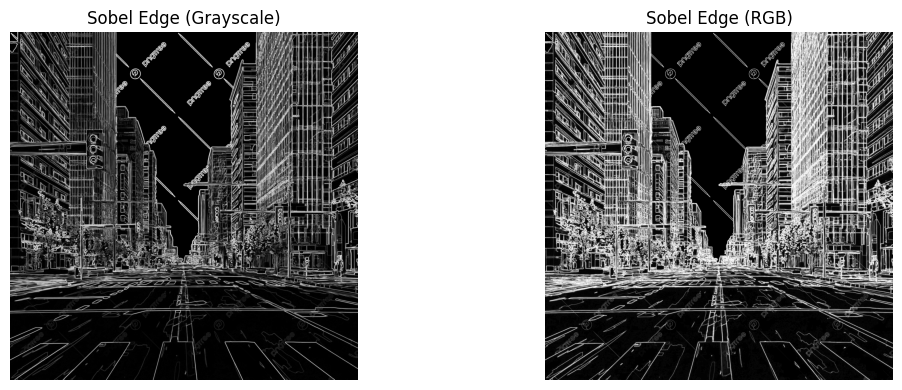

In [11]:
sx = cv2.Sobel(blur_gray, cv2.CV_64F, 1, 0, 3)
sy = cv2.Sobel(blur_gray, cv2.CV_64F, 0, 1, 3)
sobel_gray = np.uint8(np.clip(cv2.magnitude(sx, sy), 0, 255))

sr = cv2.magnitude(cv2.Sobel(r, cv2.CV_64F, 1, 0, 3), cv2.Sobel(r, cv2.CV_64F, 0, 1, 3))
sg = cv2.magnitude(cv2.Sobel(g, cv2.CV_64F, 1, 0, 3), cv2.Sobel(g, cv2.CV_64F, 0, 1, 3))
sb = cv2.magnitude(cv2.Sobel(b, cv2.CV_64F, 1, 0, 3), cv2.Sobel(b, cv2.CV_64F, 0, 1, 3))
sobel_rgb = np.uint8(np.clip(np.sqrt(sr**2 + sg**2 + sb**2), 0, 255))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(sobel_gray, cmap="gray"); axes[0].set_title("Sobel Edge (Grayscale)"); axes[0].axis("off")
axes[1].imshow(sobel_rgb, cmap="gray"); axes[1].set_title("Sobel Edge (RGB)"); axes[1].axis("off")
plt.tight_layout(); plt.show()

Line Detection (Canny + Hough)

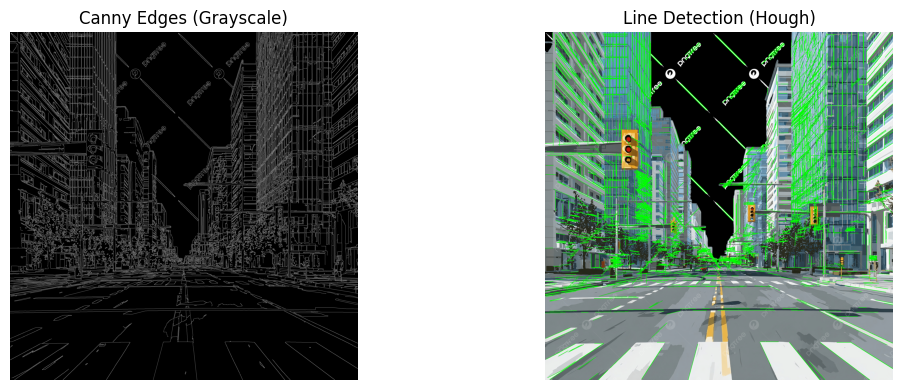

In [12]:
edges_gray = cv2.Canny(blur_gray, 50, 150)

lines = cv2.HoughLinesP(edges_gray, 1, np.pi/180, 100, minLineLength=50, maxLineGap=10)
line_img = img.copy()
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(line_img, (x1, y1), (x2, y2), (0, 255, 0), 2)

line_img_rgb = cv2.cvtColor(line_img, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(edges_gray, cmap="gray"); axes[0].set_title("Canny Edges (Grayscale)"); axes[0].axis("off")
axes[1].imshow(line_img_rgb); axes[1].set_title("Line Detection (Hough)"); axes[1].axis("off")
plt.tight_layout(); plt.show()